# Model Training

In this notebook, we will train a baseline linear regression model.

Linear regression tries to find a straight-line relationship between the input features and the price we want to predict. It is a good first model because it is simple and easier to interpret than many advanced models.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CLEANED_DATA_PATH = PROJECT_ROOT / "data" / "cleaned_house_data.csv"

%matplotlib inline

In [2]:
house_data = pd.read_csv(CLEANED_DATA_PATH)
house_data.head()

,total_rooms,total_bedrooms,housing_median_age,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,880.0,129.0,41.0,126.0,8.3252,452600.0,False,False,True,False
1,7099.0,1106.0,21.0,1138.0,8.3014,358500.0,False,False,True,False
2,1467.0,190.0,52.0,177.0,7.2574,352100.0,False,False,True,False
3,1274.0,235.0,52.0,219.0,5.6431,341300.0,False,False,True,False
4,1627.0,280.0,52.0,259.0,3.8462,342200.0,False,False,True,False


## Separate features and target

The features are the columns the model uses to make predictions. The target is the value we want to predict.

In [3]:
target_column = "median_house_value"

X = house_data.drop(columns=[target_column])
y = house_data[target_column]

print("Feature columns:")
print(X.columns.tolist())

Feature columns:
['total_rooms', 'total_bedrooms', 'housing_median_age', 'households', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


## Split into training and test data

The model learns from the training data. The test data is held back so we can evaluate the model on examples it has not seen before.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_SEED,
)

print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")

Training rows: 16512
Test rows: 4128


## Train the linear regression model

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Make predictions

In [6]:
predictions = model.predict(X_test)
predictions[:5]

array([ 69627.58690048,  80039.49038178, 192575.37431664, 268990.66521452,
       234895.73938539])

## Evaluate the model

We will use three common regression metrics:

- Mean Absolute Error: average absolute prediction error.
- Root Mean Squared Error: gives more weight to larger errors.
- R-squared: shows how much variation in price is explained by the model.

In [7]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

metrics = pd.DataFrame(
    {
        "Metric": ["Mean Absolute Error", "Root Mean Squared Error", "R-squared"],
        "Value": [mae, rmse, r2],
    }
)

metrics

,Metric,Value
0,Mean Absolute Error,53011.605490
1,Root Mean Squared Error,73590.122803
2,R-squared,0.586732


## Actual prices vs predicted prices

If the model predicted perfectly, the points would fall close to the diagonal line.

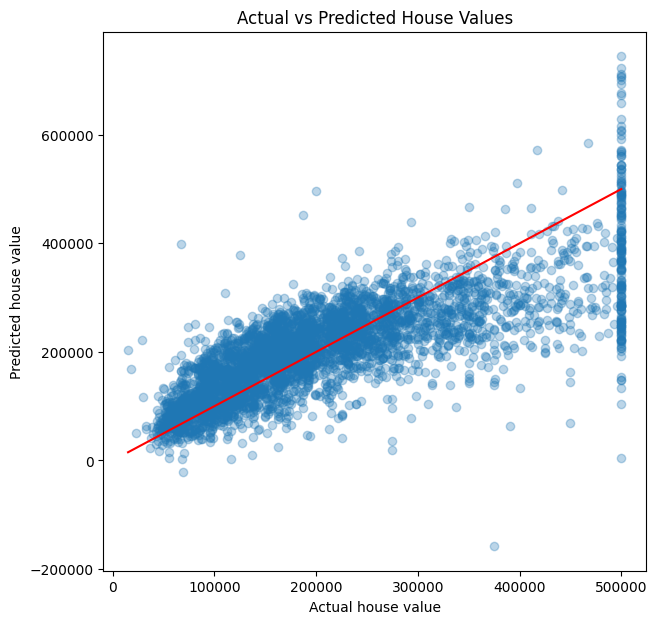

In [8]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, predictions, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.title("Actual vs Predicted House Values")
plt.xlabel("Actual house value")
plt.ylabel("Predicted house value")
plt.show()

## Model coefficients

Coefficients show how each feature is connected to the prediction when the other features are held constant. Large positive values push the prediction up, while negative values push it down.

In [9]:
coefficients = pd.DataFrame(
    {
        "Feature": X.columns,
        "Coefficient": model.coef_,
    }
).sort_values(by="Coefficient", ascending=False)

coefficients

,Feature,Coefficient
6,ocean_proximity_ISLAND,161452.544229
4,median_income,42795.551129
8,ocean_proximity_NEAR OCEAN,17532.762328
7,ocean_proximity_NEAR BAY,11361.958557
2,housing_median_age,1231.553152
1,total_bedrooms,141.479361
0,total_rooms,-14.715908
3,households,-48.732823
5,ocean_proximity_INLAND,-64998.087019


## Results interpretation

Write your interpretation here after running the notebook.

Consider these questions:

- What is the average prediction error in dollars?
- Is the R-squared score high, moderate, or low?
- Which features have the largest positive or negative coefficients?
- Does this simple linear model seem like a good first baseline?

## What I learned

Use this section for your own reflection after running the project.

Possible prompts:

- What did you learn about preparing data for machine learning?
- What did the model do well?
- Where did the model struggle?
- What would you try next?